In [1]:
import warnings

import torch
import torch.nn as nn

from transformers import AutoModelForCausalLM, AutoTokenizer

from lm_eval import evaluator
from lm_eval.models.huggingface import HFLM


model_name = "unsloth/Llama-3.2-1B-Instruct"
# model_name = "unsloth/Llama-3.2-1B"
# model_name = "HuggingFaceTB/SmolLM2-360M"
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.bfloat16,
    attn_implementation="flash_attention_2",
    device_map={"": 0},
)
tokenizer = AutoTokenizer.from_pretrained(model_name)

In [ ]:
model.config

In [2]:
HFLM(pretrained=model, tokenizer=tokenizer)

In [4]:
results = evaluator.simple_evaluate(
    model=HFLM(
        pretrained=model,
        tokenizer=tokenizer,
        batch_size=64,
    ),
    tasks=[
        # "arc_easy",
        # "hellaswag",
        # "gsm8k",
        # "mmlu_pro",
        # "global_mmlu_en_stem",
        # "hendrycks_math_algebra",
        # "squadv2",
        "babilongv2_qa1_under_4k_instruct",
        # "babilong_qa1",
    ],
    verbosity="WARNING",
    # batch_size=64,
    batch_size=64,
    # batch_size=3,
    # limit=4,
    apply_chat_template=True,
)
print(results["results"])

2025-10-05:00:32:00 WARNING  [models.huggingface:111] `pretrained` model kwarg is not of type `str`. Many other model arguments may be ignored. Please do not launch via accelerate or use `parallelize=True` if passing an existing model this way.
2025-10-05:00:32:00 WARNING  [models.huggingface:335] Passed an already-initialized model through `pretrained`, assuming single-process call to evaluate() or custom distributed integration
2025-10-05:00:32:09 WARNING  [evaluator:480] Chat template formatting change affects loglikelihood and multiple-choice tasks. See docs/chat-template-readme.md for details.
Running generate_until requests: 100%|██████████| 4000/4000 [02:31<00:00, 26.34it/s] 


{'babilongv2_qa1_under_4k_instruct': {' ': ' ', 'alias': 'babilongv2_qa1_under_4k_instruct'}, 'babilongv2_qa1_0k_instruct': {'alias': ' - babilongv2_qa1_0k_instruct', 'acc,none': 0.681, 'acc_stderr,none': 'N/A'}, 'babilongv2_qa1_1k_instruct': {'alias': ' - babilongv2_qa1_1k_instruct', 'acc,none': 0.668, 'acc_stderr,none': 'N/A'}, 'babilongv2_qa1_2k_instruct': {'alias': ' - babilongv2_qa1_2k_instruct', 'acc,none': 0.608, 'acc_stderr,none': 'N/A'}, 'babilongv2_qa1_4k_instruct': {'alias': ' - babilongv2_qa1_4k_instruct', 'acc,none': 0.567, 'acc_stderr,none': 'N/A'}}


In [5]:
results["results"]

{'squadv2': {'alias': 'squadv2',
  'exact,none': 16.0,
  'exact_stderr,none': 'N/A',
  'f1,none': 21.330492463908435,
  'f1_stderr,none': 'N/A',
  'HasAns_exact,none': 35.55555555555556,
  'HasAns_exact_stderr,none': 'N/A',
  'HasAns_f1,none': 47.40109436424097,
  'HasAns_f1_stderr,none': 'N/A',
  'NoAns_exact,none': 0.0,
  'NoAns_exact_stderr,none': 'N/A',
  'NoAns_f1,none': 0.0,
  'NoAns_f1_stderr,none': 'N/A',
  'best_exact,none': 57.0,
  'best_exact_stderr,none': 'N/A',
  'best_f1,none': 57.0,
  'best_f1_stderr,none': 'N/A'}}

In [ ]:
# {'arc_easy': {'alias': 'arc_easy',
#   'acc,none': 0.6544612794612794,
#   'acc_stderr,none': 0.0097579487306703,
#   'acc_norm,none': 0.6077441077441077,
#   'acc_norm_stderr,none': 0.010018744689650043}}

# {'hellaswag': {'alias': 'hellaswag',
#   'acc,none': 0.4778928500298745,
#   'acc_stderr,none': 0.0049849017528463884,
#   'acc_norm,none': 0.6366261700856403,
#   'acc_norm_stderr,none': 0.004799882248494812}}


# {
#     "global_mmlu_en_stem": {
#         "alias": "global_mmlu_en_stem",
#         "acc,none": 0.32608695652173914,
#         "acc_stderr,none": 0.06988152725357215,
#     }
# }

## generative

### Test dummy

In [2]:
!pip install langdetect immutabledict -q

In [ ]:
from lm_eval.models.dummy import DummyLM
from lm_eval import evaluator

results = evaluator.simple_evaluate(
    model=DummyLM(),
    tasks=[
        "arc_easy",
        # "leaderboard_bbh",
        # "leaderboard_gpqa",
        # "leaderboard_ifeval",
    ],
    verbosity="WARNING",
)
results["results"]

100%|██████████| 45979/45979 [00:00<00:00, 629327.64it/s]


{'arc_easy': {'alias': 'arc_easy',
  'acc,none': 0.25715488215488214,
  'acc_stderr,none': 0.008968394768971988,
  'acc_norm,none': 0.25462962962962965,
  'acc_norm_stderr,none': 0.0089394072885894},
 'leaderboard_bbh': {'acc_norm,none': 0.2886651622982121,
  'acc_norm_stderr,none': np.float64(0.005564061696272715),
  'alias': 'leaderboard_bbh'},
 'leaderboard_bbh_boolean_expressions': {'alias': ' - leaderboard_bbh_boolean_expressions',
  'acc_norm,none': 0.508,
  'acc_norm_stderr,none': 0.03168215643141381},
 'leaderboard_bbh_causal_judgement': {'alias': ' - leaderboard_bbh_causal_judgement',
  'acc_norm,none': 0.5828877005347594,
  'acc_norm_stderr,none': 0.03615450931140827},
 'leaderboard_bbh_date_understanding': {'alias': ' - leaderboard_bbh_date_understanding',
  'acc_norm,none': 0.128,
  'acc_norm_stderr,none': 0.021172081336336506},
 'leaderboard_bbh_disambiguation_qa': {'alias': ' - leaderboard_bbh_disambiguation_qa',
  'acc_norm,none': 0.352,
  'acc_norm_stderr,none': 0.03026

In [4]:
results["results"]

{'arc_easy': {'alias': 'arc_easy',
  'acc,none': 0.25715488215488214,
  'acc_stderr,none': 0.008968394768971988,
  'acc_norm,none': 0.25462962962962965,
  'acc_norm_stderr,none': 0.0089394072885894},
 'leaderboard_bbh': {'acc_norm,none': 0.2886651622982121,
  'acc_norm_stderr,none': np.float64(0.005564061696272715),
  'alias': 'leaderboard_bbh'},
 'leaderboard_bbh_boolean_expressions': {'alias': ' - leaderboard_bbh_boolean_expressions',
  'acc_norm,none': 0.508,
  'acc_norm_stderr,none': 0.03168215643141381},
 'leaderboard_bbh_causal_judgement': {'alias': ' - leaderboard_bbh_causal_judgement',
  'acc_norm,none': 0.5828877005347594,
  'acc_norm_stderr,none': 0.03615450931140827},
 'leaderboard_bbh_date_understanding': {'alias': ' - leaderboard_bbh_date_understanding',
  'acc_norm,none': 0.128,
  'acc_norm_stderr,none': 0.021172081336336506},
 'leaderboard_bbh_disambiguation_qa': {'alias': ' - leaderboard_bbh_disambiguation_qa',
  'acc_norm,none': 0.352,
  'acc_norm_stderr,none': 0.03026

### Custom model

In [1]:
import torch
import torch.nn as nn

from transformers import AutoModelForCausalLM, AutoTokenizer

from lm_eval import evaluator
from lm_eval.models.huggingface import HFLM


model_name = "unsloth/Llama-3.2-1B-Instruct"
# model_name = "unsloth/Llama-3.2-1B"
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.bfloat16,
    attn_implementation="flash_attention_2",
    device_map={"": 0},
)
tokenizer = AutoTokenizer.from_pretrained(model_name)

In [2]:
# from lm_eval.models.custom_model_1 import SimpleHFLM
from train_gym.massive_train.evaluation.custom_lm_eval import SimpleHFLM
from train_gym.massive_train.evaluation.custom_lm_eval_v2 import SimpleAccelerateHFLM

results = evaluator.simple_evaluate(
    model=SimpleAccelerateHFLM(
        pretrained=model,
        tokenizer=tokenizer,
        batch_size=64,
    ),
    tasks=[
        # "arc_easy",
        # "arc_easy",
        # "leaderboard_bbh",
        # "leaderboard_gpqa",
        # "leaderboard_ifeval",
        "babilongv2_qa1_0k_instruct",
    ],
    verbosity="WARNING",
    batch_size=64,
    apply_chat_template=True,
)
results["results"]

`pretrained` model kwarg is not of type `str`. Many other model arguments may be ignored. Please do not launch via accelerate or use `parallelize=True` if passing an existing model this way.
Passed an already-initialized model through `pretrained`, assuming single-process call to evaluate() or custom distributed integration
2025-10-05:00:44:33 WARNING  [evaluator:480] Chat template formatting change affects loglikelihood and multiple-choice tasks. See docs/chat-template-readme.md for details.
100%|██████████| 1000/1000 [00:00<00:00, 12871.65it/s]


custom generate_until


Running generate_until requests: 100%|██████████| 1000/1000 [00:08<00:00, 117.31it/s]


{'babilongv2_qa1_0k_instruct': {'alias': 'babilongv2_qa1_0k_instruct',
  'acc,none': 0.681,
  'acc_stderr,none': 'N/A'}}

In [ ]:
import numpy as np

metrics_result = {
    "arc_easy": {
        "alias": "arc_easy",
        "acc,none": 0.25715488215488214,
        "acc_stderr,none": 0.008968394768971988,
        "acc_norm,none": 0.25462962962962965,
        "acc_norm_stderr,none": 0.0089394072885894,
    },
    "leaderboard_bbh": {
        "acc_norm,none": 0.2886651622982121,
        "acc_norm_stderr,none": np.float64(0.005564061696272715),
        "alias": "leaderboard_bbh",
    },
    "leaderboard_bbh_boolean_expressions": {
        "alias": " - leaderboard_bbh_boolean_expressions",
        "acc_norm,none": 0.508,
        "acc_norm_stderr,none": 0.03168215643141381,
    },
    "leaderboard_bbh_causal_judgement": {
        "alias": " - leaderboard_bbh_causal_judgement",
        "acc_norm,none": 0.5828877005347594,
        "acc_norm_stderr,none": 0.03615450931140827,
    },
    "leaderboard_bbh_date_understanding": {
        "alias": " - leaderboard_bbh_date_understanding",
        "acc_norm,none": 0.128,
        "acc_norm_stderr,none": 0.021172081336336506,
    },
    "leaderboard_bbh_disambiguation_qa": {
        "alias": " - leaderboard_bbh_disambiguation_qa",
        "acc_norm,none": 0.352,
        "acc_norm_stderr,none": 0.030266288057359935,
    },
    "leaderboard_bbh_formal_fallacies": {
        "alias": " - leaderboard_bbh_formal_fallacies",
        "acc_norm,none": 0.472,
        "acc_norm_stderr,none": 0.0316364895315444,
    },
    "leaderboard_bbh_geometric_shapes": {
        "alias": " - leaderboard_bbh_geometric_shapes",
        "acc_norm,none": 0.072,
        "acc_norm_stderr,none": 0.016381005750490108,
    },
    "leaderboard_bbh_hyperbaton": {
        "alias": " - leaderboard_bbh_hyperbaton",
        "acc_norm,none": 0.488,
        "acc_norm_stderr,none": 0.03167708558254709,
    },
    "leaderboard_bbh_logical_deduction_five_objects": {
        "alias": " - leaderboard_bbh_logical_deduction_five_objects",
        "acc_norm,none": 0.204,
        "acc_norm_stderr,none": 0.02553712157454815,
    },
    "leaderboard_bbh_logical_deduction_seven_objects": {
        "alias": " - leaderboard_bbh_logical_deduction_seven_objects",
        "acc_norm,none": 0.168,
        "acc_norm_stderr,none": 0.02369281320549259,
    },
    "leaderboard_bbh_logical_deduction_three_objects": {
        "alias": " - leaderboard_bbh_logical_deduction_three_objects",
        "acc_norm,none": 0.36,
        "acc_norm_stderr,none": 0.030418764025174988,
    },
    "leaderboard_bbh_movie_recommendation": {
        "alias": " - leaderboard_bbh_movie_recommendation",
        "acc_norm,none": 0.14,
        "acc_norm_stderr,none": 0.021989409645240262,
    },
    "leaderboard_bbh_navigate": {
        "alias": " - leaderboard_bbh_navigate",
        "acc_norm,none": 0.516,
        "acc_norm_stderr,none": 0.031669985030107414,
    },
    "leaderboard_bbh_object_counting": {
        "alias": " - leaderboard_bbh_object_counting",
        "acc_norm,none": 0.06,
        "acc_norm_stderr,none": 0.015050117079158747,
    },
    "leaderboard_bbh_penguins_in_a_table": {
        "alias": " - leaderboard_bbh_penguins_in_a_table",
        "acc_norm,none": 0.2054794520547945,
        "acc_norm_stderr,none": 0.03355465401072844,
    },
    "leaderboard_bbh_reasoning_about_colored_objects": {
        "alias": " - leaderboard_bbh_reasoning_about_colored_objects",
        "acc_norm,none": 0.04,
        "acc_norm_stderr,none": 0.0124184084113013,
    },
    "leaderboard_bbh_ruin_names": {
        "alias": " - leaderboard_bbh_ruin_names",
        "acc_norm,none": 0.192,
        "acc_norm_stderr,none": 0.024960691989172022,
    },
    "leaderboard_bbh_salient_translation_error_detection": {
        "alias": " - leaderboard_bbh_salient_translation_error_detection",
        "acc_norm,none": 0.148,
        "acc_norm_stderr,none": 0.022503547243806148,
    },
    "leaderboard_bbh_snarks": {
        "alias": " - leaderboard_bbh_snarks",
        "acc_norm,none": 0.48314606741573035,
        "acc_norm_stderr,none": 0.03756094444734479,
    },
    "leaderboard_bbh_sports_understanding": {
        "alias": " - leaderboard_bbh_sports_understanding",
        "acc_norm,none": 0.456,
        "acc_norm_stderr,none": 0.0315632850612134,
    },
    "leaderboard_bbh_temporal_sequences": {
        "alias": " - leaderboard_bbh_temporal_sequences",
        "acc_norm,none": 0.232,
        "acc_norm_stderr,none": 0.02675007037486516,
    },
    "leaderboard_bbh_tracking_shuffled_objects_five_objects": {
        "alias": " - leaderboard_bbh_tracking_shuffled_objects_five_objects",
        "acc_norm,none": 0.248,
        "acc_norm_stderr,none": 0.027367497504863555,
    },
    "leaderboard_bbh_tracking_shuffled_objects_seven_objects": {
        "alias": " - leaderboard_bbh_tracking_shuffled_objects_seven_objects",
        "acc_norm,none": 0.144,
        "acc_norm_stderr,none": 0.022249407735450207,
    },
    "leaderboard_bbh_tracking_shuffled_objects_three_objects": {
        "alias": " - leaderboard_bbh_tracking_shuffled_objects_three_objects",
        "acc_norm,none": 0.32,
        "acc_norm_stderr,none": 0.029561724955241037,
    },
    "leaderboard_bbh_web_of_lies": {
        "alias": " - leaderboard_bbh_web_of_lies",
        "acc_norm,none": 0.504,
        "acc_norm_stderr,none": 0.031685198551199154,
    },
    "leaderboard_gpqa": {
        "acc_norm,none": 0.2827181208053691,
        "acc_norm_stderr,none": np.float64(0.013058858808312652),
        "alias": "leaderboard_gpqa",
    },
    "leaderboard_gpqa_diamond": {
        "alias": " - leaderboard_gpqa_diamond",
        "acc_norm,none": 0.2828282828282828,
        "acc_norm_stderr,none": 0.03208779558786751,
    },
    "leaderboard_gpqa_extended": {
        "alias": " - leaderboard_gpqa_extended",
        "acc_norm,none": 0.2875457875457875,
        "acc_norm_stderr,none": 0.01938803223075149,
    },
    "leaderboard_gpqa_main": {
        "alias": " - leaderboard_gpqa_main",
        "acc_norm,none": 0.2767857142857143,
        "acc_norm_stderr,none": 0.021161749643954845,
    },
    "leaderboard_ifeval": {
        "alias": "leaderboard_ifeval",
        "prompt_level_strict_acc,none": 0.11460258780036968,
        "prompt_level_strict_acc_stderr,none": 0.01370785356606093,
        "inst_level_strict_acc,none": 0.2290167865707434,
        "inst_level_strict_acc_stderr,none": "N/A",
        "prompt_level_loose_acc,none": 0.11460258780036968,
        "prompt_level_loose_acc_stderr,none": 0.01370785356606093,
        "inst_level_loose_acc,none": 0.2290167865707434,
        "inst_level_loose_acc_stderr,none": "N/A",
    },
}
target_metrics = ["arc_easy", "leaderboard_gpqa", "leaderboard_bbh"]

report_dict = {}
for metric_name in target_metrics:
    for key, value in metrics_result[metric_name].items():
        report_dict[f"eval/{metric_name}/{key}"] = value
report_dict

{'eval/arc_easy/alias': 'arc_easy',
 'eval/arc_easy/acc,none': 0.25715488215488214,
 'eval/arc_easy/acc_stderr,none': 0.008968394768971988,
 'eval/arc_easy/acc_norm,none': 0.25462962962962965,
 'eval/arc_easy/acc_norm_stderr,none': 0.0089394072885894,
 'eval/leaderboard_gpqa/acc_norm,none': 0.2827181208053691,
 'eval/leaderboard_gpqa/acc_norm_stderr,none': np.float64(0.013058858808312652),
 'eval/leaderboard_gpqa/alias': 'leaderboard_gpqa',
 'eval/leaderboard_bbh/acc_norm,none': 0.2886651622982121,
 'eval/leaderboard_bbh/acc_norm_stderr,none': np.float64(0.005564061696272715),
 'eval/leaderboard_bbh/alias': 'leaderboard_bbh'}

In [ ]:
{
    "babilongv2_qa1_under_4k_base": {" ": " ", "alias": "babilongv2_qa1_under_4k_base"},
    "babilongv2_qa1_0k_base": {
        "alias": " - babilongv2_qa1_0k_base",
        "acc,none": 0.523,
        "acc_stderr,none": "N/A",
    },
    "babilongv2_qa1_1k_base": {
        "alias": " - babilongv2_qa1_1k_base",
        "acc,none": 0.405,
        "acc_stderr,none": "N/A",
    },
    "babilongv2_qa1_2k_base": {
        "alias": " - babilongv2_qa1_2k_base",
        "acc,none": 0.353,
        "acc_stderr,none": "N/A",
    },
    "babilongv2_qa1_4k_base": {
        "alias": " - babilongv2_qa1_4k_base",
        "acc,none": 0.314,
        "acc_stderr,none": "N/A",
    },
    "babilongv2_qa2_under_4k_base": {" ": " ", "alias": "babilongv2_qa2_under_4k_base"},
    "babilongv2_qa2_0k_base": {
        "alias": " - babilongv2_qa2_0k_base",
        "acc,none": 0.3203203203203203,
        "acc_stderr,none": "N/A",
    },
    "babilongv2_qa2_1k_base": {
        "alias": " - babilongv2_qa2_1k_base",
        "acc,none": 0.2122122122122122,
        "acc_stderr,none": "N/A",
    },
    "babilongv2_qa2_2k_base": {
        "alias": " - babilongv2_qa2_2k_base",
        "acc,none": 0.15815815815815815,
        "acc_stderr,none": "N/A",
    },
    "babilongv2_qa2_4k_base": {
        "alias": " - babilongv2_qa2_4k_base",
        "acc,none": 0.14914914914914915,
        "acc_stderr,none": "N/A",
    },
    "babilongv2_qa3_under_4k_base": {" ": " ", "alias": "babilongv2_qa3_under_4k_base"},
    "babilongv2_qa3_0k_base": {
        "alias": " - babilongv2_qa3_0k_base",
        "acc,none": 0.14214214214214213,
        "acc_stderr,none": "N/A",
    },
    "babilongv2_qa3_1k_base": {
        "alias": " - babilongv2_qa3_1k_base",
        "acc,none": 0.16589327146171692,
        "acc_stderr,none": "N/A",
    },
    "babilongv2_qa3_2k_base": {
        "alias": " - babilongv2_qa3_2k_base",
        "acc,none": 0.18637274549098196,
        "acc_stderr,none": "N/A",
    },
    "babilongv2_qa3_4k_base": {
        "alias": " - babilongv2_qa3_4k_base",
        "acc,none": 0.1961961961961962,
        "acc_stderr,none": "N/A",
    },
    "babilongv2_qa4_under_4k_base": {" ": " ", "alias": "babilongv2_qa4_under_4k_base"},
    "babilongv2_qa4_0k_base": {
        "alias": " - babilongv2_qa4_0k_base",
        "acc,none": 0.5195195195195195,
        "acc_stderr,none": "N/A",
    },
    "babilongv2_qa4_1k_base": {
        "alias": " - babilongv2_qa4_1k_base",
        "acc,none": 0.4364364364364364,
        "acc_stderr,none": "N/A",
    },
    "babilongv2_qa4_2k_base": {
        "alias": " - babilongv2_qa4_2k_base",
        "acc,none": 0.4004004004004004,
        "acc_stderr,none": "N/A",
    },
    "babilongv2_qa4_4k_base": {
        "alias": " - babilongv2_qa4_4k_base",
        "acc,none": 0.3353353353353353,
        "acc_stderr,none": "N/A",
    },
    "babilongv2_qa5_under_4k_base": {" ": " ", "alias": "babilongv2_qa5_under_4k_base"},
    "babilongv2_qa5_0k_base": {
        "alias": " - babilongv2_qa5_0k_base",
        "acc,none": 0.6376376376376376,
        "acc_stderr,none": "N/A",
    },
    "babilongv2_qa5_1k_base": {
        "alias": " - babilongv2_qa5_1k_base",
        "acc,none": 0.5977933801404213,
        "acc_stderr,none": "N/A",
    },
    "babilongv2_qa5_2k_base": {
        "alias": " - babilongv2_qa5_2k_base",
        "acc,none": 0.5175175175175175,
        "acc_stderr,none": "N/A",
    },
    "babilongv2_qa5_4k_base": {
        "alias": " - babilongv2_qa5_4k_base",
        "acc,none": 0.43543543543543545,
        "acc_stderr,none": "N/A",
    },
}

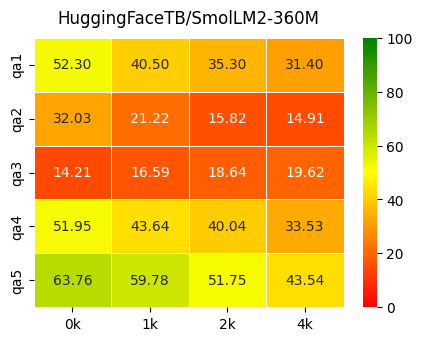

In [55]:
import numpy as np

eval_metrics = {
    "babilongv2_qa1_under_4k_base": {" ": " ", "alias": "babilongv2_qa1_under_4k_base"},
    "babilongv2_qa1_0k_base": {
        "alias": " - babilongv2_qa1_0k_base",
        "acc,none": 0.523,
        "acc_stderr,none": "N/A",
    },
    "babilongv2_qa1_1k_base": {
        "alias": " - babilongv2_qa1_1k_base",
        "acc,none": 0.405,
        "acc_stderr,none": "N/A",
    },
    "babilongv2_qa1_2k_base": {
        "alias": " - babilongv2_qa1_2k_base",
        "acc,none": 0.353,
        "acc_stderr,none": "N/A",
    },
    "babilongv2_qa1_4k_base": {
        "alias": " - babilongv2_qa1_4k_base",
        "acc,none": 0.314,
        "acc_stderr,none": "N/A",
    },
    "babilongv2_qa2_under_4k_base": {" ": " ", "alias": "babilongv2_qa2_under_4k_base"},
    "babilongv2_qa2_0k_base": {
        "alias": " - babilongv2_qa2_0k_base",
        "acc,none": 0.3203203203203203,
        "acc_stderr,none": "N/A",
    },
    "babilongv2_qa2_1k_base": {
        "alias": " - babilongv2_qa2_1k_base",
        "acc,none": 0.2122122122122122,
        "acc_stderr,none": "N/A",
    },
    "babilongv2_qa2_2k_base": {
        "alias": " - babilongv2_qa2_2k_base",
        "acc,none": 0.15815815815815815,
        "acc_stderr,none": "N/A",
    },
    "babilongv2_qa2_4k_base": {
        "alias": " - babilongv2_qa2_4k_base",
        "acc,none": 0.14914914914914915,
        "acc_stderr,none": "N/A",
    },
    "babilongv2_qa3_under_4k_base": {" ": " ", "alias": "babilongv2_qa3_under_4k_base"},
    "babilongv2_qa3_0k_base": {
        "alias": " - babilongv2_qa3_0k_base",
        "acc,none": 0.14214214214214213,
        "acc_stderr,none": "N/A",
    },
    "babilongv2_qa3_1k_base": {
        "alias": " - babilongv2_qa3_1k_base",
        "acc,none": 0.16589327146171692,
        "acc_stderr,none": "N/A",
    },
    "babilongv2_qa3_2k_base": {
        "alias": " - babilongv2_qa3_2k_base",
        "acc,none": 0.18637274549098196,
        "acc_stderr,none": "N/A",
    },
    "babilongv2_qa3_4k_base": {
        "alias": " - babilongv2_qa3_4k_base",
        "acc,none": 0.1961961961961962,
        "acc_stderr,none": "N/A",
    },
    "babilongv2_qa4_under_4k_base": {" ": " ", "alias": "babilongv2_qa4_under_4k_base"},
    "babilongv2_qa4_0k_base": {
        "alias": " - babilongv2_qa4_0k_base",
        "acc,none": 0.5195195195195195,
        "acc_stderr,none": "N/A",
    },
    "babilongv2_qa4_1k_base": {
        "alias": " - babilongv2_qa4_1k_base",
        "acc,none": 0.4364364364364364,
        "acc_stderr,none": "N/A",
    },
    "babilongv2_qa4_2k_base": {
        "alias": " - babilongv2_qa4_2k_base",
        "acc,none": 0.4004004004004004,
        "acc_stderr,none": "N/A",
    },
    "babilongv2_qa4_4k_base": {
        "alias": " - babilongv2_qa4_4k_base",
        "acc,none": 0.3353353353353353,
        "acc_stderr,none": "N/A",
    },
    "babilongv2_qa5_under_4k_base": {" ": " ", "alias": "babilongv2_qa5_under_4k_base"},
    "babilongv2_qa5_0k_base": {
        "alias": " - babilongv2_qa5_0k_base",
        "acc,none": 0.6376376376376376,
        "acc_stderr,none": "N/A",
    },
    "babilongv2_qa5_1k_base": {
        "alias": " - babilongv2_qa5_1k_base",
        "acc,none": 0.5977933801404213,
        "acc_stderr,none": "N/A",
    },
    "babilongv2_qa5_2k_base": {
        "alias": " - babilongv2_qa5_2k_base",
        "acc,none": 0.5175175175175175,
        "acc_stderr,none": "N/A",
    },
    "babilongv2_qa5_4k_base": {
        "alias": " - babilongv2_qa5_4k_base",
        "acc,none": 0.43543543543543545,
        "acc_stderr,none": "N/A",
    },
}


target_metrics = [
    # "arc_easy",
    # "hellaswag",
    # "winogrande",
    # "sciq",
    # "copa",
    # "openbookqa",
    # "mmlu_stem",
    # "mmlu_other",
    # "mmlu_social_sciences",
    # "mmlu_humanities",
    "babilongv2_qa1_0k_base",
    "babilongv2_qa1_1k_base",
    "babilongv2_qa1_2k_base",
    "babilongv2_qa1_4k_base",
    "babilongv2_qa2_0k_base",
    "babilongv2_qa2_1k_base",
    "babilongv2_qa2_2k_base",
    "babilongv2_qa2_4k_base",
    "babilongv2_qa3_0k_base",
    "babilongv2_qa3_1k_base",
    "babilongv2_qa3_2k_base",
    "babilongv2_qa3_4k_base",
    "babilongv2_qa4_0k_base",
    "babilongv2_qa4_1k_base",
    "babilongv2_qa4_2k_base",
    "babilongv2_qa4_4k_base",
    "babilongv2_qa5_0k_base",
    "babilongv2_qa5_1k_base",
    "babilongv2_qa5_2k_base",
    "babilongv2_qa5_4k_base",
]

report_dict = {}
metrics_result = eval_metrics
# print(metrics_result)
ban_keys = ["stderr", "alias", "under"]
for metric_name in target_metrics:
    for key, value in metrics_result[metric_name].items():
        eval_key = f"eval_{metric_name}_{key}"
        if not any(ban_key in eval_key for ban_key in ban_keys):
            report_dict[eval_key] = value
dataset_name = "babilongv2"
rows = [
    "qa1",
    "qa2",
    "qa3",
    "qa4",
    "qa5",
]
cols = [
    "0k",
    "1k",
    "2k",
    "4k",
]

babilong_matrix = np.zeros((len(rows), len(cols)))


for key in report_dict:
    if dataset_name in key:
        for i, row in enumerate(rows):
            for j, col in enumerate(cols):
                if row in key and col in key:
                    babilong_matrix[i, j] = report_dict[key]


from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import matplotlib.pyplot as plt
import io
from PIL import Image

cmap = LinearSegmentedColormap.from_list("ryg", ["red", "yellow", "green"], N=256)

fig, ax = plt.subplots(1, 1, figsize=(5 * 1, 3.5))
sns.heatmap(
    babilong_matrix * 100,
    cmap=cmap,
    vmin=0,
    vmax=100,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    xticklabels=cols,
    yticklabels=rows,
    ax=ax,
)
model_name = "HuggingFaceTB/SmolLM2-360M"
ax.set_title(f"{model_name}", pad=20, y=0.95)
# fig.savefig("heatmap_with_title.png", dpi=100)
buf = io.BytesIO()

fig.savefig(buf, format="png", bbox_inches="tight")

buf.seek(0)
pil_image = Image.open(buf)


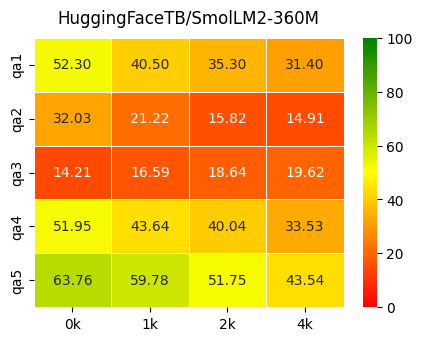

In [56]:
pil_image